# NS07 Tutorial C - Robustness Under Failure and Attack

**Lecture:** NS07 - Degree Distributions, Scale-Free Networks, and Robustness

**Reading:** Albert, Jeong, and Barabasi (2000)

## Learning goals
- Use the lecture robustness variable
  $$
  S(q) = \frac{\text{size of the largest connected component after removing a fraction } q}{N}.
  $$
- Simulate **random failure** and **targeted attack** computationally.
- Connect robustness curves to degree heterogeneity and hubs.
- Compare synthetic model networks to a real transportation network.


In [7]:
from netsci_utils import *
import pandas as pd

set_seeds()
%matplotlib inline


def matched_models(reference_graph):
    n = reference_graph.number_of_nodes()
    avg_degree = np.mean([degree for _, degree in reference_graph.degree()])
    p = avg_degree / (n - 1)
    m = max(1, round(avg_degree / 2))
    er = nx.erdos_renyi_graph(n, p, seed=RANDOM_SEED)
    ba = nx.barabasi_albert_graph(n, m, seed=RANDOM_SEED)
    return er, ba


def _lcc_fraction(H, n0):
    """LCC size as a fraction of the *original* network size n0."""
    if H.number_of_nodes() == 0:
        return 0.0
    return max(len(c) for c in nx.connected_components(H)) / n0


def _single_removal_curve(G, fractions, strategy='random', seed=RANDOM_SEED):
    H = G.copy()
    n0 = G.number_of_nodes()
    checkpoints = sorted({int(round(q * n0)) for q in fractions})
    values = {0: _lcc_fraction(H, n0)}
    rng = np.random.default_rng(seed)
    removed = 0

    if strategy == 'random':
        order = list(H.nodes())
        rng.shuffle(order)
        cursor = 0
        for target in checkpoints[1:]:
            while removed < target and cursor < len(order):
                node = order[cursor]
                cursor += 1
                if node in H:
                    H.remove_node(node)
                    removed += 1
            values[target] = _lcc_fraction(H, n0)

    elif strategy == 'targeted':
        for target in checkpoints[1:]:
            while removed < target and H.number_of_nodes() > 0:
                node = max(H.degree, key=lambda item: item[1])[0]
                H.remove_node(node)
                removed += 1
            values[target] = _lcc_fraction(H, n0)
    else:
        raise ValueError('strategy must be random or targeted')

    return np.array([values[int(round(q * n0))] for q in fractions])


def robustness_curve(G, fractions, strategy='random', trials=1, seed=RANDOM_SEED):
    if strategy == 'random' and trials > 1:
        curves = [
            _single_removal_curve(G, fractions, strategy='random', seed=seed + trial)
            for trial in range(trials)
        ]
        return np.mean(curves, axis=0)
    return _single_removal_curve(G, fractions, strategy=strategy, seed=seed)


def q_threshold(fractions, curve, threshold=0.5):
    below = np.where(curve <= threshold)[0]
    if len(below) == 0:
        return np.nan
    return fractions[below[0]]


def initial_removed_degrees(G, n_remove=20, strategy='random', seed=RANDOM_SEED):
    degree0 = dict(G.degree())
    rng = np.random.default_rng(seed)
    if strategy == 'random':
        nodes = list(G.nodes())
        rng.shuffle(nodes)
        order = nodes[:n_remove]
    elif strategy == 'targeted':
        order = [node for node, _ in sorted(G.degree, key=lambda item: item[1], reverse=True)[:n_remove]]
    else:
        raise ValueError('strategy must be random or targeted')
    return np.array([degree0[node] for node in order])

---
## 1. Structural setup: homogeneous versus heterogeneous networks

We compare three networks with similar size and mean degree:
- **ER**: a narrow random benchmark,
- **BA**: a model with hubs,
- **OpenFlights USA**: a real transportation network.

This lets us ask the NS07 question directly: what changes when hubs are present?


In [8]:
openflights = load_openflights_usa()
er, ba = matched_models(openflights)

robustness_graphs = {
    'ER': er,
    'BA': ba,
    'OpenFlights USA': openflights,
}

rows = []
for name, graph in robustness_graphs.items():
    degrees = np.array([degree for _, degree in graph.degree()])
    rows.append({
        'network': name,
        'n': graph.number_of_nodes(),
        'm': graph.number_of_edges(),
        '<k>': degrees.mean(),
        'max k': degrees.max(),
        'kappa': heterogeneity_kappa(graph),
        'largest component (initial)': largest_component_fraction(graph),
    })
summary_df = pd.DataFrame(rows)
print(summary_df.round(2).to_string(index=False))


        network   n    m   <k>  max k  kappa  largest component (initial)
             ER 546 2704  9.90     22  10.88                         1.00
             BA 546 2705  9.91    104  20.69                         1.00
OpenFlights USA 546 2781 10.19    153  54.47                         0.99


**Interpretation.**
- ER and BA are matched roughly in size and mean degree.
- The large differences in **max degree** and **$\kappa$** quantify how much more heterogeneous BA and OpenFlights are.
- That heterogeneity is the mechanism we test in the robustness simulations.


---
## 2. Robustness curves: random failure versus targeted attack

We remove a fraction $q$ of the nodes and track
$$
S(q),
$$
the fraction of nodes that remain in the largest connected component.

- **Random failure** removes randomly chosen nodes.
- **Targeted attack** removes the highest-degree node available at each step.


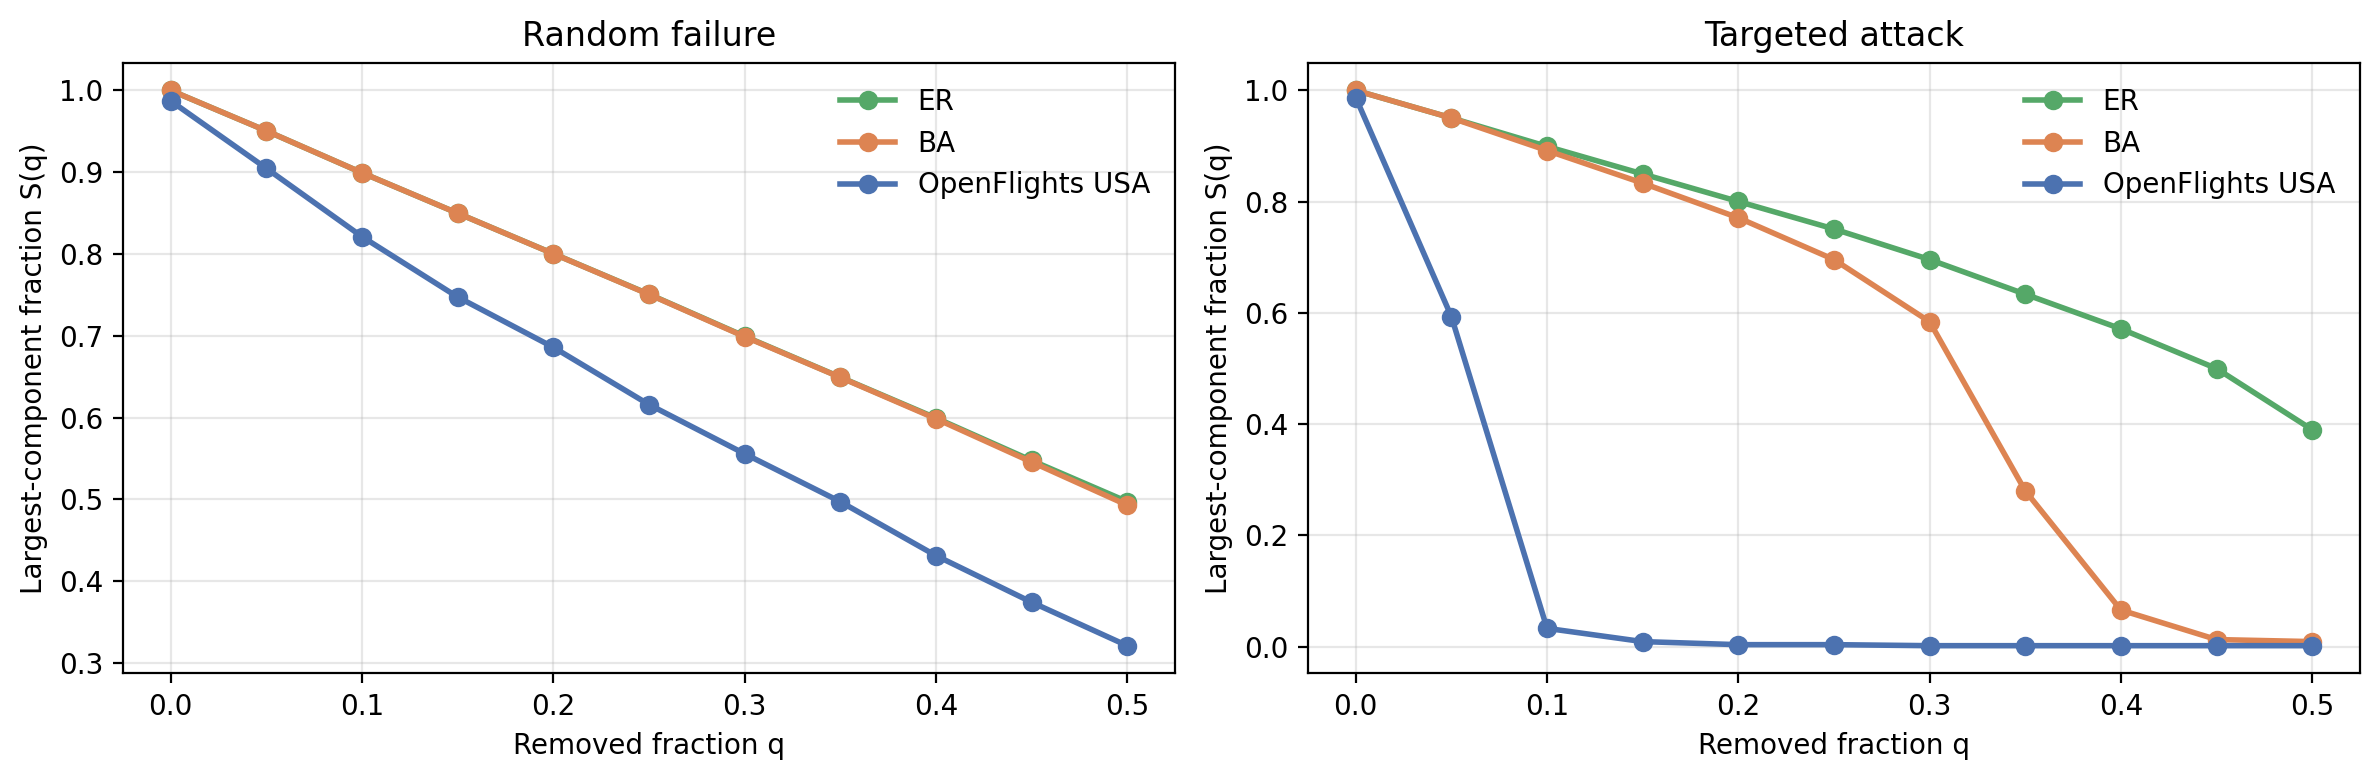

In [9]:
fractions = np.linspace(0, 0.50, 11)

random_curves = {
    name: robustness_curve(graph, fractions, strategy='random', trials=20)
    for name, graph in robustness_graphs.items()
}
targeted_curves = {
    name: robustness_curve(graph, fractions, strategy='targeted')
    for name, graph in robustness_graphs.items()
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

color_map = {
    'ER': CATEGORY_PALETTE['green'],
    'BA': CATEGORY_PALETTE['orange'],
    'OpenFlights USA': CATEGORY_PALETTE['blue'],
}

for name in robustness_graphs:
    axes[0].plot(fractions, random_curves[name], marker='o', linewidth=2, color=color_map[name], label=name)
    axes[1].plot(fractions, targeted_curves[name], marker='o', linewidth=2, color=color_map[name], label=name)

style_axis(
    axes[0],
    title='Random failure',
    xlabel='Removed fraction q',
    ylabel='Largest-component fraction S(q)',
    legend=True,
)
style_axis(
    axes[1],
    title='Targeted attack',
    xlabel='Removed fraction q',
    ylabel='Largest-component fraction S(q)',
    legend=True,
)
plt.show()


**Interpretation.**
- Under **random failure**, most removed nodes have low degree because low-degree nodes are the majority.
- Under **targeted attack**, the process removes shortcuts and hubs first.
- Heterogeneous networks can therefore look resilient to random loss and fragile to attack at the same time.


---
## 3. A compact quantitative comparison

A useful summary is the critical fraction needed to push the largest component below one half of the original network.


In [10]:
threshold_rows = []
for name in robustness_graphs:
    threshold_rows.append({
        'network': name,
        'q where random failure gives S(q) <= 0.5': q_threshold(fractions, random_curves[name], threshold=0.5),
        'q where targeted attack gives S(q) <= 0.5': q_threshold(fractions, targeted_curves[name], threshold=0.5),
    })
threshold_df = pd.DataFrame(threshold_rows)
print(threshold_df.round(2).to_string(index=False))


        network  q where random failure gives S(q) <= 0.5  q where targeted attack gives S(q) <= 0.5
             ER                                      0.50                                       0.45
             BA                                      0.50                                       0.35
OpenFlights USA                                      0.35                                       0.10


---
## 4. Why attack is worse: which nodes get removed?

The lecture explanation is mechanistic:
- random failure mainly removes low-degree nodes,
- targeted attack removes hubs.

We make that visible by comparing the degrees of the first 20 removed airports in the real network.


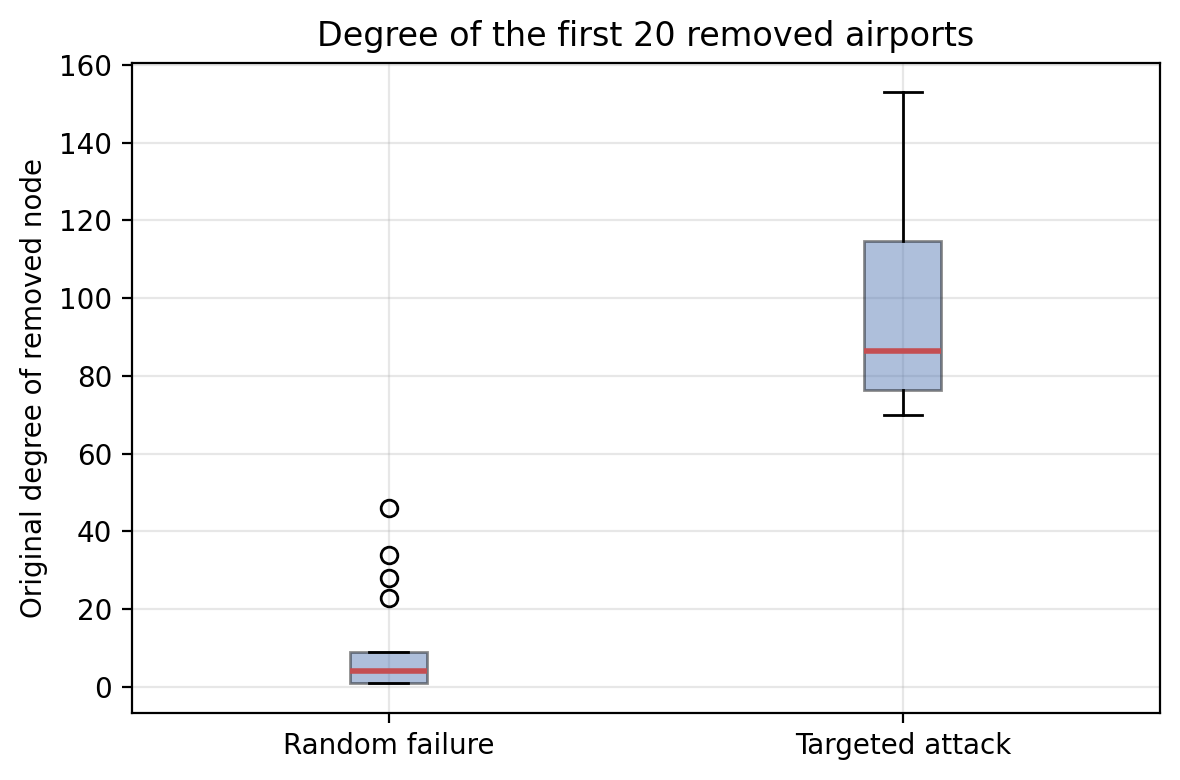

Mean degree removed under random failure : 9.30
Mean degree removed under targeted attack: 100.30


In [11]:
random_removed = initial_removed_degrees(openflights, n_remove=20, strategy='random')
targeted_removed = initial_removed_degrees(openflights, n_remove=20, strategy='targeted')

fig, ax = plt.subplots(figsize=FIGURE_SIZE_SMALL)
ax.boxplot(
    [random_removed, targeted_removed],
    tick_labels=['Random failure', 'Targeted attack'],
    patch_artist=True,
    boxprops={'facecolor': CATEGORY_PALETTE['blue'], 'alpha': 0.45},
    medianprops={'color': CATEGORY_PALETTE['red'], 'linewidth': 2},
)
style_axis(
    ax,
    title='Degree of the first 20 removed airports',
    ylabel='Original degree of removed node',
)
plt.show()

print(f"Mean degree removed under random failure : {random_removed.mean():.2f}")
print(f"Mean degree removed under targeted attack: {targeted_removed.mean():.2f}")


---
## 5. Real-world implication: the airport network is resilient and vulnerable in different ways

In a transportation network:
- random cancellations usually affect peripheral airports,
- coordinated disruption at major hubs can fragment national connectivity much faster.

We list the main hubs that a degree-based attack would hit first.


In [12]:
hub_rows = []
for airport, degree in sorted(openflights.degree, key=lambda item: item[1], reverse=True)[:12]:
    hub_rows.append({
        'airport': airport,
        'name': openflights.nodes[airport].get('name', airport),
        'degree': degree,
    })
hub_df = pd.DataFrame(hub_rows)
print(hub_df.to_string(index=False))


airport                                                       name  degree
    ATL           Hartsfield Jackson Atlanta International Airport     153
    ORD                       Chicago O'Hare International Airport     149
    DEN                               Denver International Airport     148
    DFW                    Dallas Fort Worth International Airport     138
    MSP Minneapolis-St Paul International/Wold-Chamberlain Airport     117
    DTW                  Detroit Metropolitan Wayne County Airport     114
    LAS                             McCarran International Airport     113
    CLT                    Charlotte Douglas International Airport     110
    IAH               George Bush Intercontinental Houston Airport     101
    PHL                         Philadelphia International Airport      88
    LAX                          Los Angeles International Airport      85
    DCA                  Ronald Reagan Washington National Airport      85


## Takeaway

- Robustness in NS07 is measured through the largest connected component $S(q)$.
- The same hubs that shorten paths also create **targeted vulnerability**.
- Heterogeneity, captured by $\kappa$, explains why BA and OpenFlights behave differently from ER.
- In real systems such as transportation or communication networks, resilience depends strongly on whether failures are random or hub-focused.
